<a href="https://colab.research.google.com/github/cl1nch/PY-TUT-2026/blob/main/data_and_files.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/OWL-ML/IBFW-PY-2026-Tutorial/blob/main/data_and_files.ipynb)

*(Tip: Ctrl/Cmd + click to open in a new tab)*


# Laden und Speichern von Daten / *Loading and saving data!*

### Pickle
Wir beginngen mit dem Laden und Speichern von arbiträren Python Objekten in einem binären Format.

Python besitzt eine eigene Library zur Serialisierung zu diesem Zweck, genannt "Pickle".

---

*Let's start with loading and saving arbitrary Python objects in the form of a binary file.*

*Python has its own serialization library for this purpose, called "Pickle".*

In [129]:
import pickle

data_array = [1,2,3]

with open('data_array.pickle', 'wb') as f:
    pickle.dump(data_array, f)

with open('data_array.pickle', 'rb') as f:
    data_array_pickle = pickle.load(f)

print(data_array)

print(data_array_pickle)

[1, 2, 3]
[1, 2, 3]


Ein binäres Format impliziert, dass wir jegliche Art von Daten speichern können - inklusive ausführbaren Code in der Form von Strings. Das kann sehr hilfreich sein, um schnell Dinge zu speichern. Gleichzeitig ist dadurch ein Risiko bedingt, wenn wir den Inhalt eines Pickle files nicht kennen und diesem nicht vertrauen. Vorsicht ist also geboten!

---

*A binary file means you can technically store any kind of data, including executable code itself in the form of strings. This can be an advantage to quickly save things, but also invokes potential risks when loading pickle files whose content you are not aware of. So please be cautious!*

In [130]:
import pickle

data_array = [1,2,3,"a","b","c"]

with open('data_array.pickle', 'wb') as f:
    pickle.dump(data_array, f)

with open('data_array.pickle', 'rb') as f:
    data_array_pickle = pickle.load(f)

print(data_array)

[1, 2, 3, 'a', 'b', 'c']


Pickle ist daher am besten geeignet als vorrübergehender Schritt in der Anwendung, z.B. zum debuggen oder prototyping. Abseits der Sicherheitsfragestellung, ist ein weiterer Nachteil das Fehlen von Struktur in einer für Menschen lesbaren form. Für letzteres gibt es bessere Formate, die gleichzeitig auch geeigneter zur Langzeitarchivierung sind.

---

*Pickle is thus best suited as a preliminary step, e.g. when debugging or wanting to prototype quickly. Apart from security, an obvious disadvantage is that the data is not necessarily structured in a tidy human interpretable form. To this end, there exist better formats, that are also amenable to long term storage.*

### Numpy array format (NPY)

Als Alternative zu pickle, aber weiterhin im binären Format, bieten sich numpy arrays an. Diese können im gleichnamigen Numpy Array Format gespeichert werden.

Arrays selbst sind nicht unbedingt geeignet zur Langzeitarchivierung. Dennoch sind sie sehr populär geworden, insbesondere z.B. durch das maschinelle Lernen.

---

*An alternative to pickle, also in binary format, is the numpy array format, which as the name implies can be used to save numpy arrays.*

*Arrays themselves are also not necessarily the most useful for long-term storage, although storing arrays directly has become quite common in e.g. machine learning.*

In [131]:
import numpy as np

data_array = np.zeros(5)

np.save('data_array.npy', data_array)
data_array_npy = np.load('data_array.npy')

# the .savez() function also allows you to store multiple arrays into one file,
# as an alternative to multi-dimensional Tensors that you need to slice
np.savez('data_arrays.npz', data_array0=data_array, data_array1=data_array)
data_arrays = np.load('data_arrays.npz')
data_arrays['data_array0']

array([0., 0., 0., 0., 0.])

# Pandas zum Laden und Handhabung von tabularen Daten / *Pandas loading and handling of tabular data(sets)*

Oft werden wir mit menschlich lesbaren Daten konfrontiert, z.B. solche die im .csv Format erzeugt wurden. Dieses Format kann zwar keine arbiträren Daten speichern und ist auch nicht sonderlich speichereffizient, es kann aber sehr "sauber" gestaltet werden und ist dadurch geeignet für langere Archivierung.

---

*A lot of times we will be faced with human readable data that was created e.g. in the .csv format. The latter can't store arbitrary data and is not very space efficient, but it is amenable to long term storage as it's very tidy.*

*The pandas library gives us a lot of utility to load, modify, analyze, and safe such data in a format called a DataFrame.*

In [132]:
import pandas as pd

url = "https://raw.githubusercontent.com/scikit-learn/scikit-learn/main/sklearn/datasets/data/iris.csv"
iris = pd.read_csv(url)

print(type(iris))

<class 'pandas.core.frame.DataFrame'>


Die Funktionen .head() und .describe() erlauben es und die ersten wenigen Zeilen eines DataFrames auszugeben, bzw. einige wenige zusammenfassende Statistiken zu erzeugen. Wir werden später eine Übung zum besseren Verständnis haben und lernen wann diese Statistiken sinnvoll sind. Zuerst, gehen wir aber durch die einfachen Funktionalitäten um uns einen Überblick zu verschaffen.

---

*The functions .head() and .describe() allow us to print the first few lines of the DataFrame and respectively, summarize some key statistics. We will have an excercise later to get a better understanding for whether these summary statistics are meaningful or when they are not. For now, let's walk through some functionality.*

In [133]:
iris.head()

,150,4,setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [134]:
iris.describe()

,150,4,setosa,versicolor,virginica
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


Wir können auch .dtypes aufrufen um uns die jeweiligen Datentypen der einzelnen Spalten des DataFrames ausgeben zu lassen.

---

*We can also call .dtypes to get an understanding for what kind of types are stored in each column of the DataFrame*

In [135]:
iris.dtypes

,0
150,float64
4,float64
setosa,float64
versicolor,float64
virginica,int64


### Operationen auf Zeilen und Spalten des DataFrames / *Operating on a DataFrame's rows and columns*

Wahrscheinlich ist es bereits aufgefallen. Unser DataFrame ist im Prinzip eine Tabelle mit Reihen und Spalten, und somikt ein zwei-dimensionaler Array. Analog dazu, können wir Spalten und Reihen individuell indizieren.

---

*As you may have already seen, our DataFrame is essentially a table in the form of rows and columns - a two-dimensional array so to speak. In analogy, we can therefore index specific columns and their row entries.*

In [136]:
iris[0:2]

,150,4,setosa,versicolor,virginica
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0


In [137]:
iris["setosa"]

,setosa
0,1.4
1,1.4
2,1.3
3,1.5
4,1.4
...,...
145,5.2
146,5.0
147,5.2
148,5.4


In [138]:
iris.setosa.describe()

,setosa
count,150.000000
mean,3.758000
std,1.765298
min,1.000000
25%,1.600000
50%,4.350000
75%,5.100000
max,6.900000


In [139]:
iris.setosa.head()

,setosa
0,1.4
1,1.4
2,1.3
3,1.5
4,1.4


Das bedeutet auch, dass wir fortgeschrittene Logik anwenden können, z.B. um bestimmte Einträge zu extrahieren oder zu filtern. Als Beispiel, sowie bei numpy arrays auch, können wir z.B. eine boolsche Bedingung als Index benutzen.

---

*This means that we can also use more advanced logic to extract or filter entries. As an example, as with numpy arrays, we could use boolean indexing.*

In [140]:
iris[iris.setosa > 6.0]

,150,4,setosa,versicolor,virginica
105,7.6,3.0,6.6,2.1,2
107,7.3,2.9,6.3,1.8,2
109,7.2,3.6,6.1,2.5,2
117,7.7,3.8,6.7,2.2,2
118,7.7,2.6,6.9,2.3,2
122,7.7,2.8,6.7,2.0,2
130,7.4,2.8,6.1,1.9,2
131,7.9,3.8,6.4,2.0,2
135,7.7,3.0,6.1,2.3,2


In [141]:
iris[iris.setosa > 3.0].count()

,0
150,99
4,99
setosa,99
versicolor,99
virginica,99


### Hierarchisches Datenformat / *Hierarchical Data Format*

Keines der oberen Datenformat ist besonders speichereffizient. Um größere Datenmengen effektiv teilen zu können (in binärem Format) existieren daher andere Lösungen. Gängig ist hier das hierarchische Datenformat (HDF), z.b. in HDF5 in der aktuellen fünften Version.

---

*Neither of the above are particularly space efficient in terms of occupied storage. For effective sharing of larger amounts of data in binary format, it is thus common to make use of the hierarchical data format, HDF5 for short in the current version 5.*

In [142]:
iris.to_hdf('iris.h5', key='dataset', mode='w')
dataset_hdf5 = pd.read_hdf('iris.h5')
print(dataset_hdf5)

     150    4  setosa  versicolor  virginica
0    5.1  3.5     1.4         0.2          0
1    4.9  3.0     1.4         0.2          0
2    4.7  3.2     1.3         0.2          0
3    4.6  3.1     1.5         0.2          0
4    5.0  3.6     1.4         0.2          0
..   ...  ...     ...         ...        ...
145  6.7  3.0     5.2         2.3          2
146  6.3  2.5     5.0         1.9          2
147  6.5  3.0     5.2         2.0          2
148  6.2  3.4     5.4         2.3          2
149  5.9  3.0     5.1         1.8          2

[150 rows x 5 columns]


# Text und Bilder / *Text and Images*

Wir haben gesehen, wie wir gemischte oder numerische Daten laden, speichern, und manipulieren können. Für manche Daten beiten sich zusätlizh dedizierte Formate an, z.B. für Text und Bilder. Für diese Arten von Daten gibt es Formate, die besser für Menschen interpretierbar sind.  

---

*We have looked at how to load, save, and manipulate formats that are amenable to numerical content or arbitrarily mixed data. Let's look at the two specific cases of text and image formats, for which more options that are easier for humans to interpret exist.*

### .txt files

Wir starten zuerst einen Download mit dem wget Systembefehl um Shakespeares Sonnetten aus einem Internetrepository zu laden.

Damit wir diesen Download nicht jedes mal starten wenn wir den Code ausführen und die Inhalte schon verfügbar sind, überprüfen wir weiterhin ob die Datei im angegeben Pfad schon existiert.

Um sich davon zu überzeugen, kann gerne getestet werden was passiert wenn dieser Check nicht eingefügt ist.

---

*First, let us make use of the wget system command to download Shakespeare's Sonnets from the Web.*

*Let us also make use of the Path library, to quickly check whether the file already exists on our systems. If not, we will download it, if so, we will skip another repeated download.*

*If you feel like it, you can try what happens when you do not do this check.*

In [143]:
from pathlib import Path

sonnets_file = Path("sonnets.txt")
if not sonnets_file.exists():
  #boolean check, ob die datei schon vorhanden ist
    !wget https://humanum.arts.cuhk.edu.hk/humftp/E-text/Shakespeare/sonnets.txt

# replace with our own file later

Wir können dieses Textfile mit Pythons integrierter open und read Funktionalität öffnen.

---

*We can open this file with the basic open and read functions in-built into Python.*

In [144]:
# Open shakespeare text file and read the data
with open('sonnets.txt', 'r') as f:
    text = f.read()

# as with any string, we can print an excerpt of the text
print(text[271:708])



FROM fairest creatures we desire increase,
That thereby beauty's rose might never die,
But as the riper should by time decease,
His tender heir might bear his memory:
But thou, contracted to thine own bright eyes,
Feed'st thy light'st flame with self-substantial fuel,
Making a famine where abundance lies,
Thyself thy foe, to thy sweet self too cruel.
Thou that art now the world's fresh ornament
And only herald to the gaudy spring,



Abhängig von unserem exakten Interesse, möchten wir im Allgemeinen den Text modifizieren.

Um ein Beispiel zu nennen: bereits frühe Methoden der künstlichen Intelligenz für Textvervollständigung oder Generierung basieren auf der Sequenz der einzelnen Zeichen. Hier ist es üblich jedes Zeichen in eine Zahl zu überführen, damit später Rechneoperationen wie Matrizenmultiplikation ausgeführt werden könnnen. Eine simple Art solch ein "encoding" zu erreichen ist es jedes Zeichen in alphabetischer Reihenfolge einer steigenden Zahl zuzuordnen. Für unseren ausgegebenen Ausschnitt an Text, können wir uns dann die entsprechende Zahlenreihenfolge anschauen.

---

*Depending on what we will be interested in, we would like to modify the text respectively.*

*For instance, if we were to use early AI methods for text generation/completion, we may be interested in the sequence of characters. As such, it is common to create a mapping from the characters to numbers so that we can do matrix calculations with numerical data. One such way is to simply replace every character with the corresponding integer in an alphabetical sequence. If we print our excerpt, we can now see the corresponding numerical values of each character.*

In [145]:
# We create two dictionaries:
# 1. int2char, which maps integers to characters
# 2. char2int, which maps characters to integers
chars = tuple(set(text))
int2char = dict(enumerate(chars))
char2int = {ch: ii for ii, ch in int2char.items()}

# Encode the text
encoded = np.array([char2int[ch] for ch in text])

# Again showing the excerpt, but this time as integers
encoded[:200]

array([31,  9, 18, 19, 36, 38,  8, 16, 14,  5,  0, 33, 38, 22,  6,  3, 23,
        0, 39, 38, 40, 18, 53, 42,  7, 36, 21,  7, 53, 43,  7, 38, 12,  7,
       15, 12, 38, 19, 36, 38, 57, 17, 41, 43, 12,  7, 36, 27, 38, 17, 56,
       38,  3, 17, 29, 27, 38,  5,  7, 15, 19, 57, 53, 13, 38,  9, 17, 17,
       13, 36, 47, 48, 10, 10, 10, 34, 40,  6, 39, 39, 20,  9, 40, 10, 10,
       10, 10,  9,  6, 38,  9, 11, 20, 38,  6, 39,  5, 58, 38, 14, 20, 32,
       20,  9,  9, 20, 35, 38,  6, 54, 10,  9, 11, 20, 40, 20, 38,  0, 39,
       40, 16,  0, 39, 32, 38, 40,  6, 39, 39, 20,  9, 40, 10,  3, 35, 47,
       38, 26, 47, 38, 11, 47, 38, 23,  5,  5, 38, 11, 23,  8,  8,  0, 39,
       20, 40, 40, 10, 23, 39, 22, 38,  9, 11, 23,  9, 38, 20,  9, 20, 35,
       39,  0,  9, 58, 10,  8, 35,  6,  3,  0, 40, 20, 22, 38, 14, 58, 10,
        6, 16, 35, 38, 20, 62, 20, 35, 52,  5,  0, 62,  0])

### Bilder / *Image files*

Um Bilder besser zu verstehen laden wir das bekannte "Fabiobild" und benutzen die PIL library zum Öffnen. Im Anschluss können wir die display() Funktion benutzen um das Bild anzuzeigen.

---

Similarly, for images let us download the famous "Fabio" image and use the PIL library to open it. We can then use the display() function to show the image.

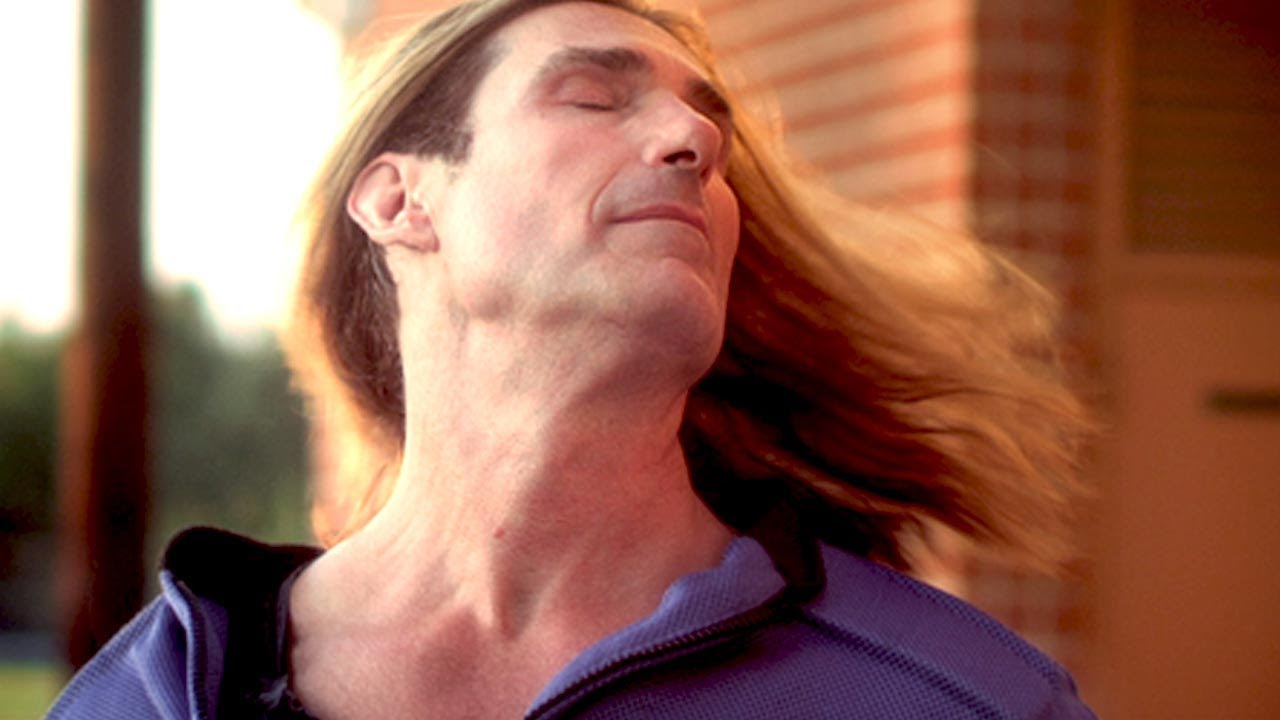

In [146]:
import requests
from PIL import Image

img_url = "https://media.boingboing.net/wp-content/uploads/2016/03/fabio.jpg"
img = Image.open(requests.get(img_url, stream=True).raw)
display(img)

Es gibt viele verschiedene Arten Bilder zu öffnen. PIL ist eine der populären Methoden. Unabhängig wie das Bild geöffnet wird, kann ein Bild als Matrix interpretiert werden. Diese enthält Reihen und Spalten (Pixel) und Farbkanäle (allgemein 3 für RGB, es gibt aber auch andere Format wie CKMY).

Dies macht es uns einfach das Bild als 3-dimensionalen numpy array zu interpretieren und dann auch so zu behandeln.

---

*There are many different kinds of ways to load images, with PIL being one of the more well-known ways. Independently, an image can be interpreted as a Matrix, that contains rows and columns for height and width respectively, and color channels (e.g. 3 for RGB, but you could also use CKMY or other formats).*

*This fact also makes it straightforward to interpret images as 3-dimensional numpy arrays and most libraries will allow us to do a straightforward conversion.*

In [147]:
import numpy as np
img = np.array(img)

print("image shape: ", img.shape)
print("image dtype: ", img.dtype)

image shape:  (720, 1280, 3)
image dtype:  uint8


Als Konsequenz können wir ein Bild analog zu einem numpy array manipulieren. Z.B. entspricht eine einfache Zoom Operation der Wahl eines entsprechenden Slices des Bildes. Slicing der Farbdimension würde entsprechend Farben modifizieren.


---

*In turn, this implies that we can manipulate the image as we would do with numpy arrays. For instance, a zoom into the image corresponds to selecting a particular slice of the image, slicing the color dimension would modify the color, etc.*


In [148]:
# get one specific pixel value - Remember, R-G-B
img[300,300,:]

array([253, 193, 131], dtype=uint8)

array([[[254, 247, 205],
        [251, 242, 199],
        [249, 238, 193],
        ...,
        [201, 136,  98],
        [202, 137,  99],
        [203, 138, 100]],

       [[254, 247, 205],
        [251, 242, 199],
        [250, 239, 194],
        ...,
        [202, 137,  99],
        [203, 138, 100],
        [203, 138, 100]],

       [[255, 248, 206],
        [253, 244, 201],
        [251, 240, 195],
        ...,
        [203, 138, 100],
        [204, 139, 101],
        [204, 139, 101]],

       ...,

       [[127, 111,  86],
        [135, 115,  91],
        [145, 121,  97],
        ...,
        [  5,   0,   0],
        [  8,   0,   0],
        [  8,   0,   0]],

       [[121, 107,  81],
        [128, 110,  86],
        [138, 116,  93],
        ...,
        [  7,   0,   1],
        [  8,   0,   0],
        [  7,   0,   0]],

       [[117, 102,  79],
        [123, 107,  82],
        [133, 112,  91],
        ...,
        [  4,   0,   0],
        [  7,   0,   0],
        [  6,   0,   0]]], dtype=uint8)
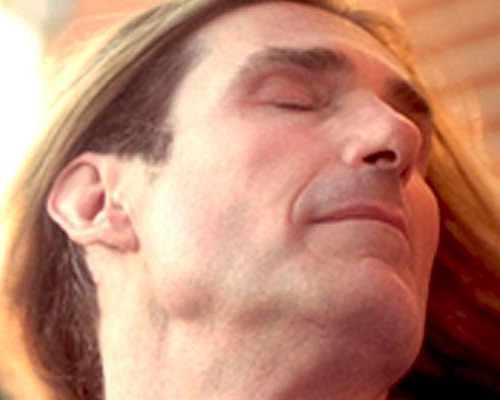

In [149]:
# get a 2d slice of the image, with all color channels
sub_img = img[0:400, 300:800,:]
display(sub_img)

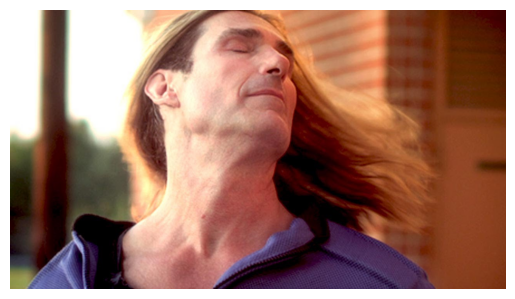

In [150]:
import matplotlib.pyplot as plt
%matplotlib inline
fig = plt.figure()
plt.imshow(img)
plt.axis('off')
plt.show()

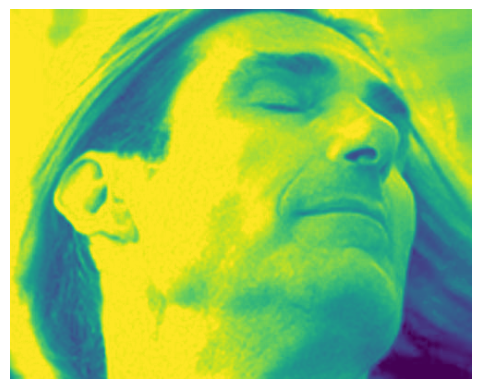

In [151]:
# get a 2d-slice of the image, with only the red channel
fig = plt.figure()
sub_img = img[0:400, 300:800, 0]
plt.imshow(sub_img)
plt.axis('off')
plt.show()

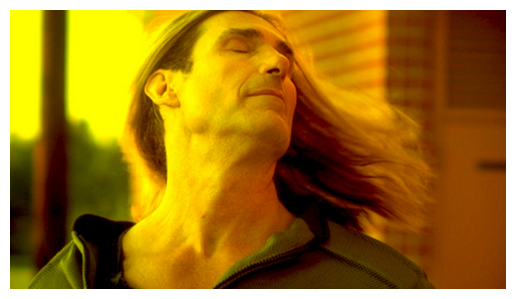

In [152]:
# set the blue-channel to zero
fig = plt.figure()
img[:,:,2] = 0
plt.imshow(img)
plt.axis('off')
plt.show()

### Eine Zusammenfassung / *A final summary*

Das Aalto Scicomp Tutorial on Python for Scientific computing (https://aaltoscicomp.github.io/python-for-scicomp/data-formats/) enthält eine gute visuelle Zusammenfassung verschiedener Datenformat (die wir nicht weiter im Detail behandeln werden) und der entsprechenden Vor- und Nachteile.

---

*The Aalto Scicomp Tutorial on Python for Scientific computing (https://aaltoscicomp.github.io/python-for-scicomp/data-formats/) provides a nice summary of different data formats (most of which we will not explore here) and their respective advantages and disadvantages, for you to get an overview.*

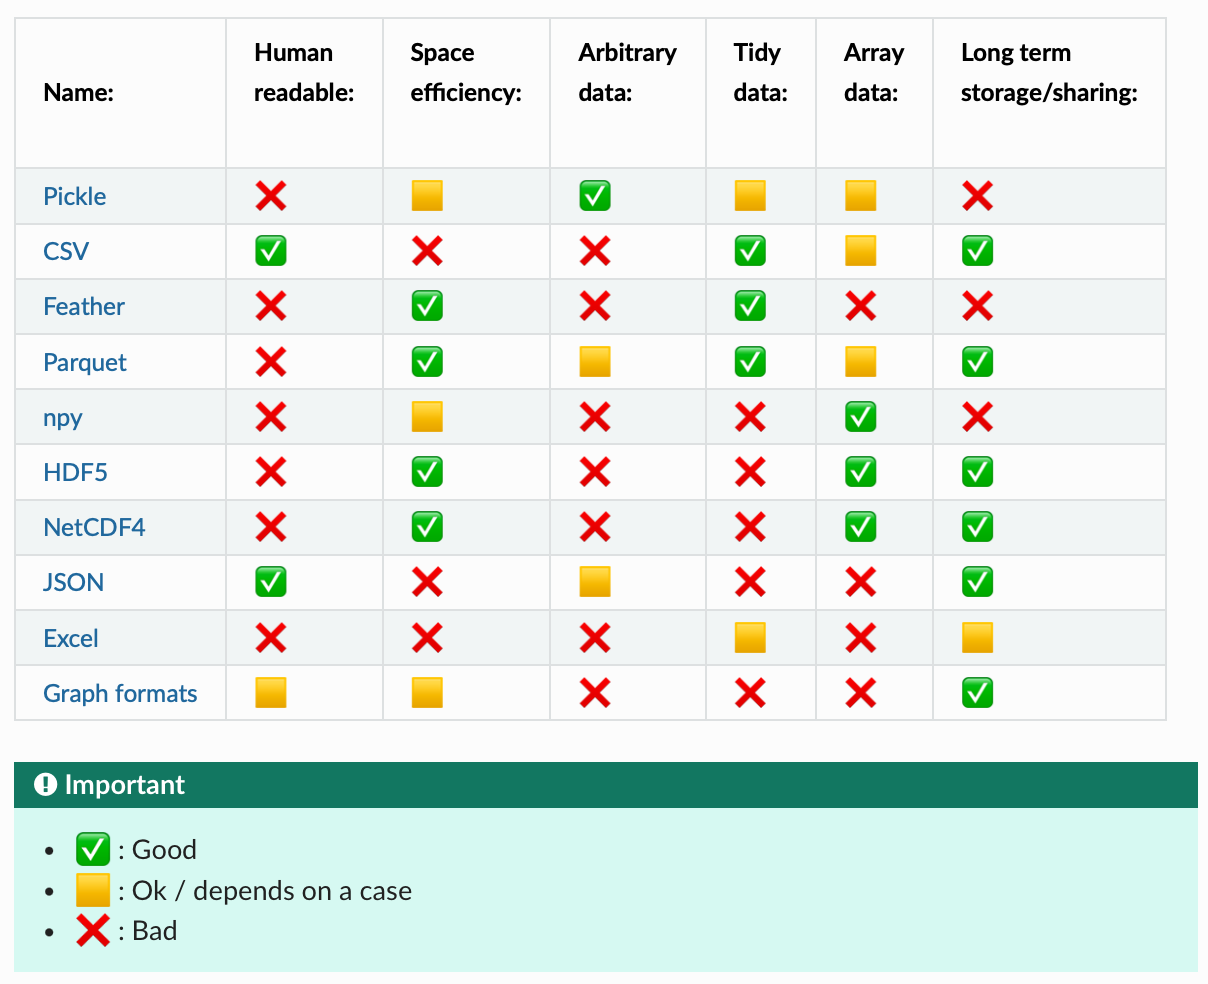

# Aufgabe: DatenFrames erstellen / *Exercise: Creating DataFrames*

Der Grund, warum das obige Pandas Dataset in der Praxis „einfach“ zu handhaben ist, liegt darin, dass es gut strukturiert ist. Prinzipiell können wir auch DataFrames haben, die nicht sauber so organisiert sind. Sauber bedeutet hier, dass jede Variable in einer eigenen Spalte gespeichert ist und jede Zeile eine Beobachtung darstellt.

In vielen Fällen, zum Beispiel beim Erstellen oder Erfassen eigener Daten, möchten wir jedoch selbst ein solch sinnvolles DataFrame erstellen. Es gibt viele Möglichkeiten, dies zu tun, die in der Pandas Dokumentation beschrieben sind. Ein Ansatz wäre beispielsweise auf Basis von NumPy-Arrays, Listen und Dictionaries.

* Schaue in die Dokumentation für pandas DataFrame und finde heraus, wie ein solches erstellt werden kann.
* Erstelle ein erstes DataFrame mithilfe früherer Covid-Daten, die unter https://www.worldometers.info/coronavirus/#countries verfügbar sind. Wähle der Einfachheit halber drei Länder aus, z. B. USA, Frankreich und Deutschland. Erstelle ein DataFrame, das die entsprechenden Spaltennamen und Werte für Country, Total Cases, Total Deaths, Total Recovered und Population enthält.
* Nachdem ein funktionierendes DataFrame erstellt wurde, füge eine Spalte hinzu, die eine URL zu einer Flagge des jeweiligen Landes enthält. Besuche dazu die folgende Website https://www.countries-ofthe-world.com und extrahiere die entsprechende Bild-URL, um sie als String zum DataFrame hinzuzufügen.
* Berechne schließlich den Prozentsatz der Gesamtfälle bezogen auf die Gesamtbevölkerung für jedes Land, sowie die Sterberate bezogen auf die Bevölkerung jedes Landes. Speichere diese in zwei zusätzlichen DataFrame-Spalten.
* Speichere das fertige DataFrame als CSV-Datei mittels der .to_csv-Funktion von Pandas. Lade die CSV herunter und öffne diese in einem bevorzugten Programm (Excel, Numbers, LibreOffice usw.), um zu überprüfen, ob alles korrekt funktioniert hat.

---

*The reason the above pandas dataset is "easy" to handle in practice is that it is well structured. In principle, you could also have DataFrames that aren't nicely sorted into each variable being saved in its own column with each row representing an observation.*

*In a lot of cases, for instance when creating or acquiring your own data, you will want to create such a meaningful DataFrame yourself. There are many ways to do this, described in the documentation of pandas, but one way would be on the basis of numpy arrays, lists, and dictionaries.*

* *Check the documentation for pandas DataFrame and find out how to create one yourself.*
* *Create an initial DataFrame using former Covid data available at https://www.worldometers.info/coronavirus/#countries . For simplicity, pick three countries, e.g. USA, France, Germany, and create a data frame that contains the respective column names and values for Country, Total Cases, Total Deaths, Total Recovered and Population.*
* *After creating a functioning DataFrame, add a column to the DataFrame containing a URL to a Flag of the respective country. To this end, visit the following website https://www.countries-ofthe-world.com and get the corresponding image URL to add to your DataFrame as a string.*
* *Finally, calculate the percent of total cases given the overall population for each country and similarly, the death rate across the population for reach country. Store those in two additional DataFrame columns.*
* *Save your finished DataFrame as a csv using the .to_csv function of Pandas. Download the CV and open it up in your favorite program (Excel, Numbers, Libre Office etc.) to see if you were successful.*


https://www.worldometers.info/coronavirus/#countries

In [154]:
# url = "https://www.worldometers.info/coronavirus/#countries"

data_raw = np.array([[111820082, 1219487, 109814428, 333985, 3642, 334805269],
 	[ 40138560, 167642, 	39970918, 61013, 	2556, 65584518],
  [ 38828995, 183027, 	38240600, 462891, 2182, 83883596]])

print(data_raw.shape)

countries = ['USA', 'France', 'Germany']
header = ['Country', 'Total Cases', 'Total Deaths', 'Total Recovered', 'Total Cases per 1M', 'Deaths', 'Population']

#col = np.array(country).reshape(-1, 1)
data_country = np.hstack((countries, data_raw))

final_array = np.vstack((header, data_country))

print(final_array)
print(type(final_array))

covid_data = pd.DataFrame(final_array)
covid_data.head()

covid_data[-1] = [
    'Flag',
    'https://flagpedia.net/data/flags/w580/us.png',
    'https://flagpedia.net/data/flags/w580/fr.png',
    'https://flagpedia.net/data/flags/w580/de.png'
]
covid_data.head()


(3, 6)


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 1 dimension(s) and the array at index 1 has 2 dimension(s)